In [1]:
import numpy as np
import matplotlib.pyplot as plt
from uniform_concentration import nu_plus

In [2]:
mscoco_losses = np.load('results/mscoco_losses.npz')
ntotal = int(mscoco_losses['ntotal'])
nholdout = ntotal // 2

idxh = np.array([1] * nholdout + [0] * (ntotal - nholdout)) > 0
np.random.shuffle(idxh) 

In [3]:
loss_types = ['fnp', 'fpp', 'fdp']

In [4]:
# APPDIX_F parameters based on 
# https://github.com/aangelopoulos/ltt/blob/main/core/plot_inequalities.py

def plot_comparison(loss_type, v = True):
    hold_data, data = mscoco_losses[loss_type][idxh, :], mscoco_losses[loss_type][~idxh, :]
    n = data.shape[1]
    delta = 0.1
    mu = hold_data.mean(axis = 0)
    muhat = data.mean(axis = 0)

    # NASM bound
    ub_NASM = np.minimum(muhat + np.sqrt(0.5 * n**(-1) * np.log(np.e / delta)), 1)

    # APPDIX_F bound
    m = 100
    num_grid_points = 100
    alpha = 0.2
    maxiter = 1000
    def compute_ub_APPDIX_F(muhat_val):
        return nu_plus(n, m, muhat_val, alpha, delta, maxiter, num_grid_points, 
                       v = v)
    v_compute_ub_APPDIX_F = np.vectorize(compute_ub_APPDIX_F, otypes=['float'])
    ub_APPDIX_F = v_compute_ub_APPDIX_F(muhat)

    fig, axs = plt.subplots(1, 2)
    t = np.linspace(0, 1, 100)
    # Plot the bounds
    axs[0].plot(t, mu, linestyle = '-', label = 'risk')
    axs[0].plot(t, ub_NASM, linestyle = '--', color = 'red', label = 'Bentkus')
    axs[0].plot(t, ub_APPDIX_F, linestyle = '--', color = 'green', label = 'AppF')
    axs[0].legend()
    # Plot the bound gaps
    bound_gap_NASM = ub_NASM - mu
    bound_gap_APPDIX_F = ub_APPDIX_F - mu
    axs[1].plot(t, bound_gap_NASM, label = 'Bentkus')
    axs[1].plot(t, bound_gap_APPDIX_F, label = 'AppF')
    axs[1].hlines(0, xmin=0, xmax=1, color = 'gray', linestyle = '--')
    axs[1].legend()
    plt.show()

/Users/destati/GitRepos/risk-tradeoffs-experiments-workspace/uniform_concentration.py:51: RuntimeWarning: divide by zero encountered in divide
  fac2 = 1 - (np.sqrt(1+eta) - np.sqrt(eta))**2 / (n_p * x**2 * gamma**2)
/Users/destati/GitRepos/risk-tradeoffs-experiments-workspace/uniform_concentration.py:52: RuntimeWarning: divide by zero encountered in log
  log_denom = np.log(np.maximum(0,fac1,fac2))


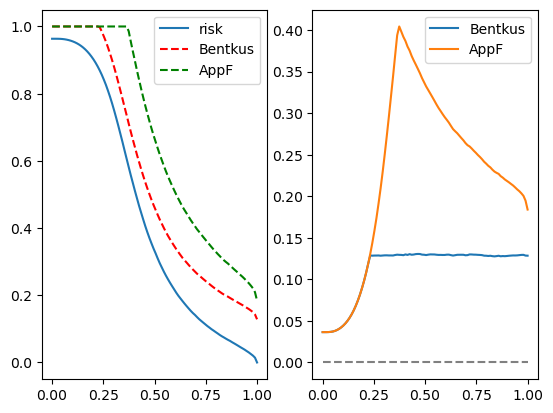

In [5]:
plot_comparison('fdp', v = False)

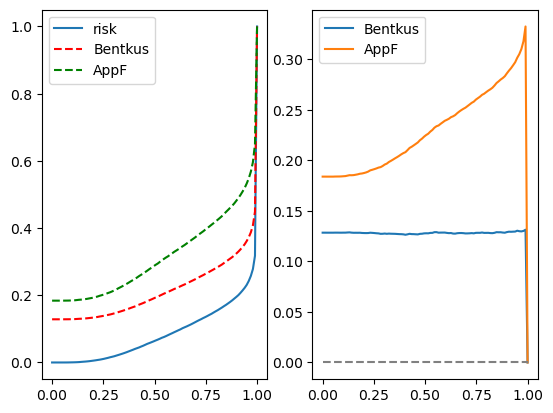

In [6]:
plot_comparison('fnp', v = False)

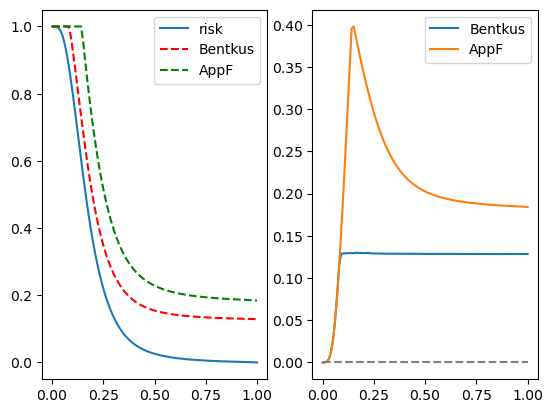

In [7]:
plot_comparison('fpp', v = False)